# Do we need blocking?

Our permutation test shuffles alt/null labels within perturbation blocks.
But does that actually matter, or would a naive (unblocked) shuffle work just as well?

Two checks:

1. Eta-squared: how much variance does perturbation explain? If the answer
   is "not much," blocking probably doesn't matter.
2. Null calibration: generate known-null data (permute labels within blocks
   to destroy any real signal), then see if both tests reject at the nominal 5% rate.
   We do this with both mean and median as the within-block summary statistic.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

BASE_DIR = Path("..").resolve()
CSV_PATH = BASE_DIR / "aggregated_results" / "aggregated_results.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected aggregated results at {CSV_PATH}. "
        "Run scripts/aggregate_conclusions.py first."
    )

df = pd.read_csv(CSV_PATH, keep_default_na=False)
datasets = sorted(df["dataset"].unique())
print(f"Datasets: {datasets}")
print(f"Perturbations: {sorted(df['perturbation'].unique())}")
print(f"Rows: {len(df)}")

Datasets: ['affairs', 'amtl', 'boxes', 'caschools', 'crofoot']
Perturbations: ['add_features', 'anonymize', 'negative_leading_statement', 'positive_leading_statement', 'shuffle_names']
Rows: 925


  dataset  eta_sq  pert_mean_range   SS_pert    SS_total
  affairs  0.0331           8.5500 2081.0800  62801.9800
     amtl  0.0063           7.0000 1619.3500 258026.8750
    boxes  0.0071           4.1750  471.2700  65957.3950
caschools  0.0071           6.1500  890.7300 125767.7550
  crofoot  0.0516           4.8000  323.7780   6269.4880
   POOLED  0.0104              NaN 5386.2080 518823.4930


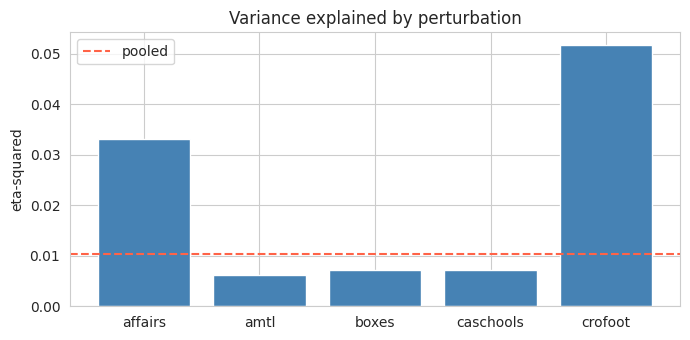

In [2]:
# Eta-squared: how much variance in scores comes from perturbation type?

eta_rows = []
ss_pert_total, ss_t_total = 0.0, 0.0

for name in datasets:
    sub = df[df["dataset"] == name]
    y = sub["response"].values.astype(float)
    grand_mean = y.mean()
    ss_t = np.sum((y - grand_mean) ** 2)

    ss_pert = 0.0
    pert_means = []
    for _, block in sub.groupby("perturbation"):
        block_y = block["response"].values.astype(float)
        block_mean = block_y.mean()
        ss_pert += len(block_y) * (block_mean - grand_mean) ** 2
        pert_means.append(block_mean)

    eta2 = ss_pert / ss_t if ss_t > 0 else 0.0
    mean_range = max(pert_means) - min(pert_means)

    eta_rows.append({
        "dataset": name,
        "eta_sq": eta2,
        "pert_mean_range": mean_range,
        "SS_pert": ss_pert,
        "SS_total": ss_t,
    })
    ss_pert_total += ss_pert
    ss_t_total += ss_t

eta_rows.append({
    "dataset": "POOLED",
    "eta_sq": ss_pert_total / ss_t_total,
    "pert_mean_range": np.nan,
    "SS_pert": ss_pert_total,
    "SS_total": ss_t_total,
})

eta_df = pd.DataFrame(eta_rows)
print(eta_df.to_string(index=False, float_format="%.4f"))

plot_df = eta_df[eta_df["dataset"] != "POOLED"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(plot_df["dataset"], plot_df["eta_sq"], color="steelblue", edgecolor="white")
ax.axhline(
    eta_df.loc[eta_df["dataset"] == "POOLED", "eta_sq"].iloc[0],
    color="tomato", linestyle="--", label="pooled",
)
ax.set_ylabel("eta-squared")
ax.set_title("Variance explained by perturbation")
ax.legend()
plt.tight_layout()
plt.show()

Eta-squared values are all pretty small (< 0.06). Perturbation type doesn't
explain a ton of variance here, so a priori we wouldn't expect blocking to
make a big difference. The next check is more rigorous.

In [3]:
# Load pre-computed calibration results (mean and median).
# Generated with `sbatch scripts/run_calibration.sh`

INSIGHTS_DIR = BASE_DIR / "insights"
AGG_NAMES = ["mean", "median"]

cal_data = {}
for agg_name in AGG_NAMES:
    path = INSIGHTS_DIR / f"calibration_results_{agg_name}.npz"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path.name}. Run: sbatch scripts/run_calibration.sh"
        )
    cal_data[agg_name] = np.load(path, allow_pickle=True)

R = int(cal_data[AGG_NAMES[0]]["R"])
B = int(cal_data[AGG_NAMES[0]]["B"])
ALPHA = 0.05

# Skip datasets that are missing alt or null in some perturbation blocks
# those would conflate blocking effects with missing-data issues.
perturbations = sorted(df["perturbation"].unique())
cal_datasets, excluded_datasets = [], []
for name in datasets:
    sub = df[df["dataset"] == name]
    has_both = all(
        (sub.loc[sub["perturbation"] == p, "distribution"].nunique() == 2)
        for p in perturbations
    )
    (cal_datasets if has_both else excluded_datasets).append(name)

if excluded_datasets:
    print(f"Excluded (incomplete data): {excluded_datasets}")

all_pvals = {}
for agg_name in AGG_NAMES:
    cal = cal_data[agg_name]
    all_pvals[agg_name] = {
        name: {"blocked": cal[f"{name}_blocked"], "unblocked": cal[f"{name}_unblocked"]}
        for name in cal_datasets
    }

print(f"R={R} replicates, B={B} permutations, datasets={cal_datasets}")
for agg_name in AGG_NAMES:
    print(f"\n  agg = {agg_name}")
    for name in cal_datasets:
        pb = all_pvals[agg_name][name]["blocked"]
        pu = all_pvals[agg_name][name]["unblocked"]
        print(f"    {name}: blocked={np.mean(pb <= ALPHA):.3f}  unblocked={np.mean(pu <= ALPHA):.3f}")

Excluded (incomplete data): ['crofoot']
R=1000 replicates, B=2000 permutations, datasets=['affairs', 'amtl', 'boxes', 'caschools']

  agg = mean
    affairs: blocked=0.047  unblocked=0.047
    amtl: blocked=0.063  unblocked=0.066
    boxes: blocked=0.059  unblocked=0.055
    caschools: blocked=0.054  unblocked=0.054

  agg = median
    affairs: blocked=0.042  unblocked=0.041
    amtl: blocked=0.057  unblocked=0.041
    boxes: blocked=0.034  unblocked=0.000
    caschools: blocked=0.053  unblocked=0.034


mean:
  dataset  alpha_hat_blocked  alpha_hat_unblocked   delta
  affairs             0.0470               0.0470  0.0000
     amtl             0.0630               0.0660  0.0030
    boxes             0.0590               0.0550 -0.0040
caschools             0.0540               0.0540  0.0000
   POOLED             0.0558               0.0555 -0.0003

median:
  dataset  alpha_hat_blocked  alpha_hat_unblocked   delta
  affairs             0.0420               0.0410 -0.0010
     amtl             0.0570               0.0410 -0.0160
    boxes             0.0340               0.0000 -0.0340
caschools             0.0530               0.0340 -0.0190
   POOLED             0.0465               0.0290 -0.0175



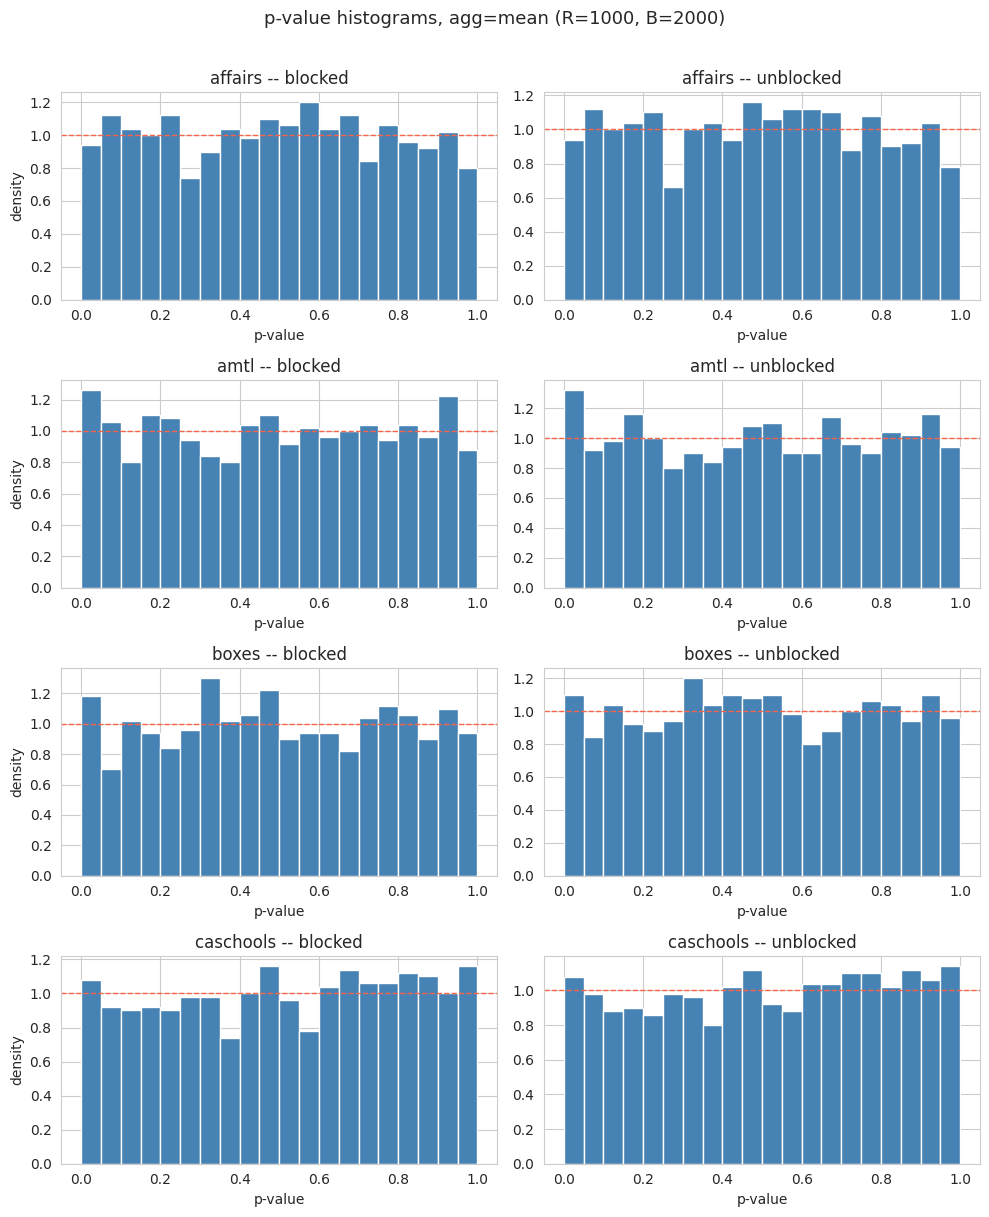

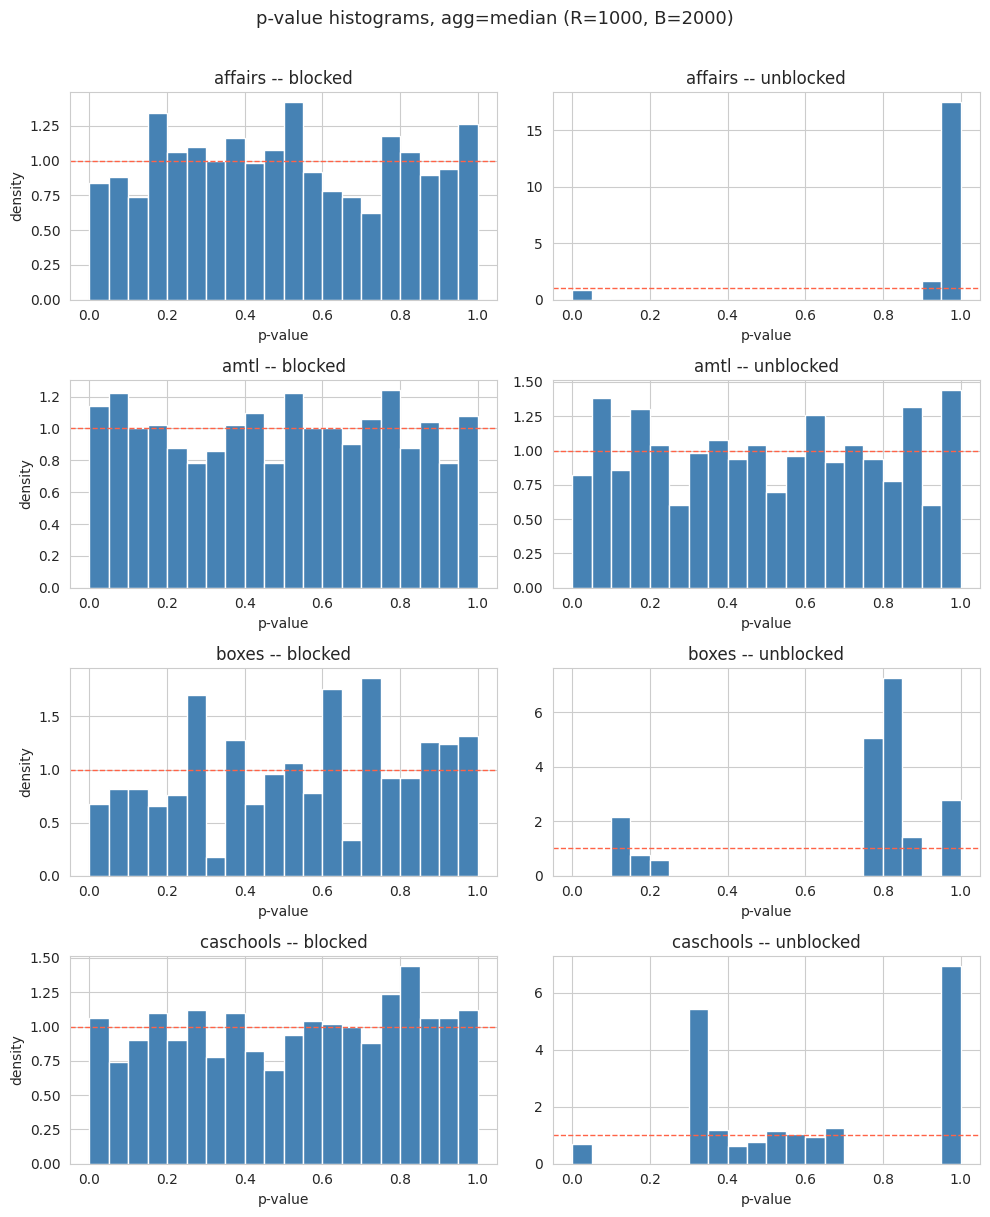

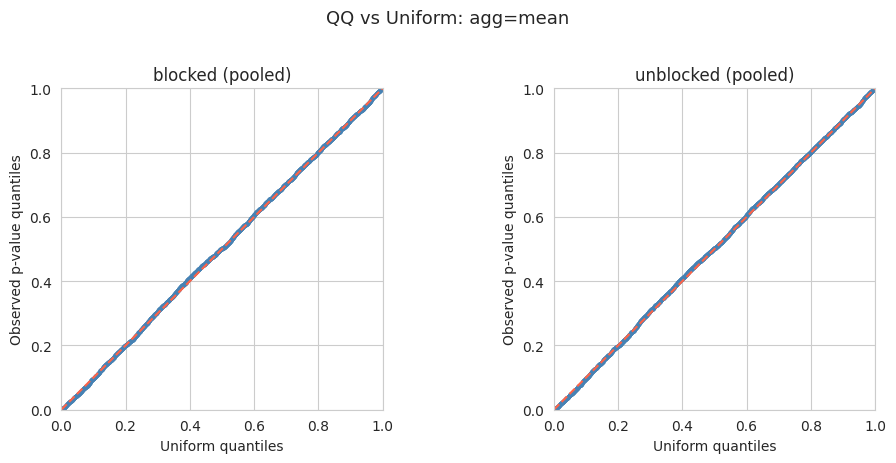

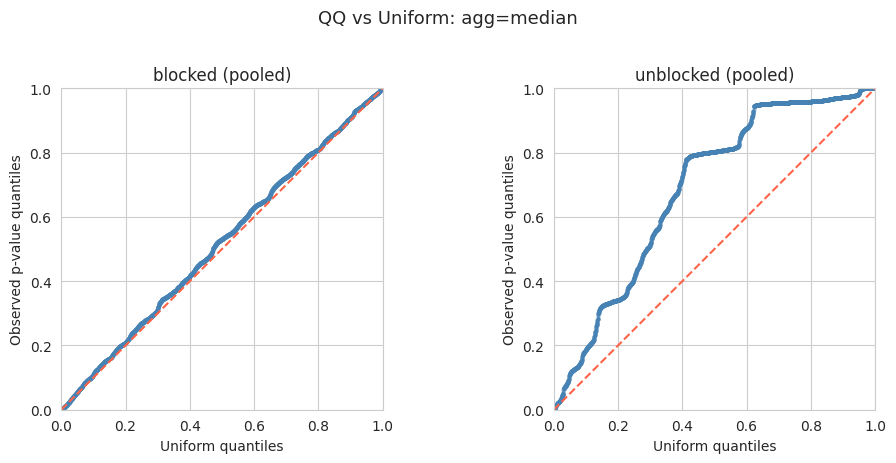

In [4]:
# Summary tables

for agg_name in AGG_NAMES:
    pvals = all_pvals[agg_name]
    pooled_b = np.concatenate([v["blocked"] for v in pvals.values()])
    pooled_u = np.concatenate([v["unblocked"] for v in pvals.values()])

    rows = []
    for name in cal_datasets:
        pb, pu = pvals[name]["blocked"], pvals[name]["unblocked"]
        rows.append({
            "dataset": name,
            "alpha_hat_blocked": np.mean(pb <= ALPHA),
            "alpha_hat_unblocked": np.mean(pu <= ALPHA),
            "delta": np.mean(pu <= ALPHA) - np.mean(pb <= ALPHA),
        })
    rows.append({
        "dataset": "POOLED",
        "alpha_hat_blocked": np.mean(pooled_b <= ALPHA),
        "alpha_hat_unblocked": np.mean(pooled_u <= ALPHA),
        "delta": np.mean(pooled_u <= ALPHA) - np.mean(pooled_b <= ALPHA),
    })
    print(f"{agg_name}:")
    print(pd.DataFrame(rows).to_string(index=False, float_format="%.4f"))
    print()

# P-value histograms (should be roughly uniform under the null)
for agg_name in AGG_NAMES:
    pvals = all_pvals[agg_name]
    fig, axes = plt.subplots(len(cal_datasets), 2, figsize=(10, 3 * len(cal_datasets)))
    for i, name in enumerate(cal_datasets):
        for j, method in enumerate(["blocked", "unblocked"]):
            ax = axes[i, j]
            pv = pvals[name][method]
            ax.hist(pv, bins=20, range=(0, 1), color="steelblue",
                    edgecolor="white", density=True)
            ax.axhline(1.0, color="tomato", linestyle="--", linewidth=1)
            ax.set_title(f"{name} -- {method}")
            ax.set_xlabel("p-value")
            if j == 0:
                ax.set_ylabel("density")
    fig.suptitle(f"p-value histograms, agg={agg_name} (R={R}, B={B})", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

# QQ plots (pooled across datasets)
for agg_name in AGG_NAMES:
    pvals = all_pvals[agg_name]
    pooled_b = np.concatenate([v["blocked"] for v in pvals.values()])
    pooled_u = np.concatenate([v["unblocked"] for v in pvals.values()])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, label, pv in [
        (axes[0], "blocked", pooled_b),
        (axes[1], "unblocked", pooled_u),
    ]:
        theoretical = np.linspace(0, 1, len(pv) + 2)[1:-1]
        observed = np.sort(pv)
        ax.scatter(theoretical, observed, s=4, alpha=0.4, color="steelblue")
        ax.plot([0, 1], [0, 1], color="tomato", linestyle="--")
        ax.set_xlabel("Uniform quantiles")
        ax.set_ylabel("Observed p-value quantiles")
        ax.set_title(f"{label} (pooled)")
        ax.set_aspect("equal")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    fig.suptitle(f"QQ vs Uniform: agg={agg_name}", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()